# 第七章作业：基于 LSTM 的中文新闻分类

本 notebook 参考第 7 章循环神经网络内容，完成一个中文新闻分类演示。流程包括：

1. 导入并解压 `cnews.zip` 数据；
2. 读取 `cnews.train.txt`、`cnews.val.txt`、`cnews.test.txt`；
3. 将中文新闻正文转换为字符 ID 序列；
4. 构建 PyTorch `Dataset` / `DataLoader`；
5. 搭建双向 LSTM 文本分类模型；
6. 训练、验证、测试并展示预测结果。

为了演示速度，默认开启 `DEMO_MODE=True`，每个类别只抽取一部分样本训练；如果想跑完整数据，把后面的 `DEMO_MODE` 改成 `False` 即可。

## 1. 导入依赖与基础配置

这里固定随机种子，便于多次运行时结果相对稳定。程序会自动选择 CUDA 或 CPU。

In [1]:
from pathlib import Path
from collections import Counter
import random
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cu128
Device: cuda


## 2. 解压并检查 CNEWS 数据

压缩包中的文本格式为：

`类别<TAB>新闻正文`

例如第一列是 `体育`、`财经` 等标签，第二列是新闻正文。

In [2]:
ROOT = Path.cwd()
ZIP_PATH = ROOT / "cnews.zip"
DATA_DIR = ROOT / "data" / "cnews"

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"没有找到数据压缩包：{ZIP_PATH}")

if not (DATA_DIR / "cnews.train.txt").exists():
    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR.parent)
    print(f"已解压到：{DATA_DIR}")
else:
    print(f"数据已存在：{DATA_DIR}")

train_path = DATA_DIR / "cnews.train.txt"
val_path = DATA_DIR / "cnews.val.txt"
test_path = DATA_DIR / "cnews.test.txt"
vocab_path = DATA_DIR / "cnews.vocab.txt"

for path in [train_path, val_path, test_path, vocab_path]:
    print(path.name, path.exists(), f"{path.stat().st_size / 1024 / 1024:.2f} MB")

数据已存在：D:\steven\hw\rgzn\hw7\data\cnews
cnews.train.txt True 124.06 MB
cnews.val.txt True 11.24 MB
cnews.test.txt True 26.23 MB
cnews.vocab.txt True 0.02 MB


In [3]:
def iter_cnews(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line or "\t" not in line:
                continue
            label, text = line.split("\t", 1)
            yield label, text


preview = []
for i, (label, text) in enumerate(iter_cnews(train_path)):
    preview.append({"label": label, "text": text[:80] + "..."})
    if i == 4:
        break

pd.DataFrame(preview)

,label,text
0,体育,马晓旭意外受伤让国奥警惕 无奈大雨格外青睐殷家军记者傅亚雨沈阳报道 来到沈阳，国奥队依然没有...
1,体育,商瑞华首战复仇心切 中国玫瑰要用美国方式攻克瑞典多曼来了，瑞典来了，商瑞华首战求3分的信心也...
2,体育,冠军球队迎新欢乐派对 黄旭获大奖张军赢下PK赛新浪体育讯12月27日晚，“冠军高尔夫球队迎新...
3,体育,辽足签约危机引注册难关 高层威逼利诱合同笑里藏刀新浪体育讯2月24日，辽足爆发了集体拒签风波...
4,体育,揭秘谢亚龙被带走：总局电话骗局 复制南杨轨迹体坛周报特约记者张锐北京报道 谢亚龙已经被公安...


## 3. 抽样读取数据

CNEWS 数据量较大。演示时采用分层随机抽样，让每个类别样本数接近，训练速度更适合演示。

In [4]:
def collect_label_names(path):
    label_names = []
    seen = set()
    for label, _ in iter_cnews(path):
        if label not in seen:
            label_names.append(label)
            seen.add(label)
    return label_names


def load_examples(path, label_names, max_per_label=None):
    buckets = {label: [] for label in label_names}
    label_set = set(label_names)

    for label, text in iter_cnews(path):
        if label in label_set:
            buckets[label].append((label, text))

    rng = random.Random(SEED)
    rows = []
    for label in label_names:
        items = buckets[label]
        if max_per_label is not None and len(items) > max_per_label:
            items = rng.sample(items, max_per_label)
        rows.extend(items)

    rng.shuffle(rows)
    counts = Counter(label for label, _ in rows)
    return rows, counts


label_names = collect_label_names(train_path)
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}

DEMO_MODE = True
TRAIN_PER_LABEL = 1000 if DEMO_MODE else None
VAL_PER_LABEL = 200 if DEMO_MODE else None
TEST_PER_LABEL = 200 if DEMO_MODE else None

train_examples, train_counts = load_examples(train_path, label_names, TRAIN_PER_LABEL)
val_examples, val_counts = load_examples(val_path, label_names, VAL_PER_LABEL)
test_examples, test_counts = load_examples(test_path, label_names, TEST_PER_LABEL)

print("类别：", label_names)
print("训练集样本数：", len(train_examples), train_counts)
print("验证集样本数：", len(val_examples), val_counts)
print("测试集样本数：", len(test_examples), test_counts)

类别： ['体育', '娱乐', '家居', '房产', '教育', '时尚', '时政', '游戏', '科技', '财经']
训练集样本数： 10000 Counter({'教育': 1000, '娱乐': 1000, '房产': 1000, '财经': 1000, '时尚': 1000, '家居': 1000, '体育': 1000, '时政': 1000, '游戏': 1000, '科技': 1000})
验证集样本数： 2000 Counter({'房产': 200, '时尚': 200, '时政': 200, '体育': 200, '家居': 200, '财经': 200, '游戏': 200, '科技': 200, '娱乐': 200, '教育': 200})
测试集样本数： 2000 Counter({'科技': 200, '游戏': 200, '娱乐': 200, '体育': 200, '房产': 200, '教育': 200, '时尚': 200, '财经': 200, '时政': 200, '家居': 200})


## 4. 构建字符表并编码文本

本作业采用字符级输入：每个汉字、标点或字符对应一个 ID。这样不依赖额外分词工具，流程更稳定。

处理方式：

- `<PAD>`：补齐短文本；
- `<UNK>`：表示词表中没有出现的字符；
- `MAX_LEN`：每条新闻最多保留的字符数，过长截断，过短补齐。

In [5]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
MAX_VOCAB_SIZE = 5000
MAX_LEN = 220

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab_tokens = [line.rstrip("\n") for line in f if line.strip()]

char2id = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for token in vocab_tokens:
    if token not in char2id:
        char2id[token] = len(char2id)
    if len(char2id) >= MAX_VOCAB_SIZE:
        break

id2char = {idx: ch for ch, idx in char2id.items()}
PAD_ID = char2id[PAD_TOKEN]
UNK_ID = char2id[UNK_TOKEN]

print("词表大小：", len(char2id))
print("前 20 个 token：", list(char2id.items())[:20])

词表大小： 4998
前 20 个 token： [('<PAD>', 0), ('<UNK>', 1), ('，', 2), ('的', 3), ('。', 4), ('一', 5), ('是', 6), ('在', 7), ('0', 8), ('有', 9), ('不', 10), ('了', 11), ('中', 12), ('1', 13), ('人', 14), ('大', 15), ('、', 16), ('国', 17), ('2', 18), ('这', 19)]


In [6]:
def encode_text(text, max_len=MAX_LEN):
    ids = [char2id.get(ch, UNK_ID) for ch in text[:max_len]]
    length = max(1, len(ids))
    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))
    return ids, length


sample_label, sample_text = train_examples[0]
sample_ids, sample_len = encode_text(sample_text)

print("原始标签：", sample_label)
print("原始文本片段：", sample_text[:100])
print("有效长度：", sample_len)
print("编码前 30 位：", sample_ids[:30])

原始标签： 教育
原始文本片段： 2010美国本科院校录取3月可申请奖学金越是名校，发录取单越晚眼下进入2月下旬，申请2010年秋季赴美学习的国内学生开始陆续收到美国大学的录取通知书了。通常他们是去年底提交申请的，每位申请人可以同时向
有效长度： 220
编码前 30 位： [18, 8, 13, 8, 101, 17, 99, 227, 354, 334, 678, 353, 49, 70, 51, 453, 349, 569, 26, 48, 515, 6, 176, 334, 2, 37, 678, 353, 330, 515]


## 5. Dataset 与 DataLoader

`Dataset` 负责把原始文本变成张量；`DataLoader` 负责按 batch 喂给模型。

In [7]:
class CNewsDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        label, text = self.examples[idx]
        token_ids, length = encode_text(text)
        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(label2id[label], dtype=torch.long),
        )


BATCH_SIZE = 64
train_loader = DataLoader(CNewsDataset(train_examples), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CNewsDataset(val_examples), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CNewsDataset(test_examples), batch_size=BATCH_SIZE, shuffle=False)

batch_x, batch_lengths, batch_y = next(iter(train_loader))
print("batch_x:", batch_x.shape)
print("batch_lengths:", batch_lengths.shape)
print("batch_y:", batch_y.shape)

batch_x: torch.Size([64, 220])
batch_lengths: torch.Size([64])
batch_y: torch.Size([64])


## 6. 搭建 LSTM 中文新闻分类模型

模型结构：

1. `Embedding`：把字符 ID 转成稠密向量；
2. `BiLSTM`：从前后两个方向提取上下文信息；
3. `Dropout`：降低过拟合；
4. `Linear`：输出每个类别的 logits。

`pack_padded_sequence` 用来告诉 LSTM 每条新闻的真实长度，避免模型把补齐的 `<PAD>` 当成有效内容。

In [8]:
class LSTMTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_size,
        num_classes,
        num_layers=1,
        dropout=0.5,
        bidirectional=True,
        padding_idx=0,
    ):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        output_size = hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_size, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            features = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            features = hidden[-1]

        logits = self.fc(self.dropout(features))
        return logits


model = LSTMTextClassifier(
    vocab_size=len(char2id),
    embed_dim=128,
    hidden_size=128,
    num_classes=len(label_names),
    num_layers=1,
    dropout=0.5,
    bidirectional=True,
    padding_idx=PAD_ID,
).to(DEVICE)

model

LSTMTextClassifier(
  (embedding): Embedding(4998, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=10, bias=True)
)

## 7. 训练与验证

训练目标是最小化交叉熵损失。每个 epoch 后在验证集上计算准确率，观察模型是否学到有效分类特征。

In [9]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x, lengths, y in loader:
        x = x.to(DEVICE)
        lengths = lengths.to(DEVICE)
        y = y.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        logits = model(x, lengths)
        loss = criterion(logits, y)

        if is_train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size

    return total_loss / total_count, total_correct / total_count


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 5 if DEMO_MODE else 8
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    }
    history.append(row)
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=1.5987, train_acc=0.4808 | val_loss=1.2328, val_acc=0.5960
Epoch 02 | train_loss=0.7902, train_acc=0.7602 | val_loss=0.9237, val_acc=0.7035
Epoch 03 | train_loss=0.5159, train_acc=0.8480 | val_loss=0.7500, val_acc=0.7680
Epoch 04 | train_loss=0.3652, train_acc=0.8930 | val_loss=0.6049, val_acc=0.8110
Epoch 05 | train_loss=0.2720, train_acc=0.9216 | val_loss=0.5325, val_acc=0.8410


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,1.598698,0.4808,1.232822,0.5960
1,2,0.790152,0.7602,0.923670,0.7035
2,3,0.515899,0.8480,0.750001,0.7680
3,4,0.365198,0.8930,0.604854,0.8110
4,5,0.271952,0.9216,0.532533,0.8410


Epoch 03 | train_loss=0.5159, train_acc=0.8480 | val_loss=0.7500, val_acc=0.7680


Epoch 04 | train_loss=0.3652, train_acc=0.8930 | val_loss=0.6049, val_acc=0.8110


Epoch 05 | train_loss=0.2720, train_acc=0.9216 | val_loss=0.5325, val_acc=0.8410


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,1.598698,0.4808,1.232822,0.5960
1,2,0.790152,0.7602,0.923670,0.7035
2,3,0.515899,0.8480,0.750001,0.7680
3,4,0.365198,0.8930,0.604854,0.8110
4,5,0.271952,0.9216,0.532533,0.8410


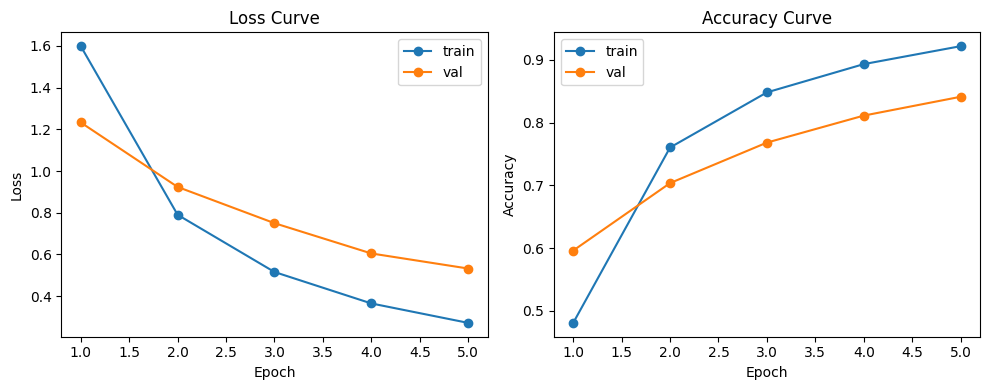

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

## 8. 测试集评估

使用从未参与训练和调参的测试集评估模型，并输出每个类别的 precision、recall、F1-score。

In [11]:
def predict_loader(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, lengths, y in loader:
            x = x.to(DEVICE)
            lengths = lengths.to(DEVICE)
            logits = model(x, lengths)
            pred = logits.argmax(dim=1).cpu().tolist()
            y_pred.extend(pred)
            y_true.extend(y.tolist())

    return y_true, y_pred


test_loss, test_acc = run_epoch(model, test_loader, criterion)
y_true, y_pred = predict_loader(model, test_loader)

print(f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")
print(classification_report(y_true, y_pred, target_names=label_names, digits=4, zero_division=0))

test_loss=0.4486, test_acc=0.8575
              precision    recall  f1-score   support

          体育     0.9548    0.9500    0.9524       200
          娱乐     0.9303    0.9350    0.9327       200
          家居     0.7122    0.4950    0.5841       200
          房产     0.7056    0.8150    0.7564       200
          教育     0.8967    0.8250    0.8594       200
          时尚     0.9150    0.9150    0.9150       200
          时政     0.8826    0.9400    0.9104       200
          游戏     0.9330    0.9050    0.9188       200
          科技     0.7808    0.8550    0.8162       200
          财经     0.8545    0.9400    0.8952       200

    accuracy                         0.8575      2000
   macro avg     0.8566    0.8575    0.8541      2000
weighted avg     0.8566    0.8575    0.8541      2000



C:\Users\steven\AppData\Local\Temp\ipykernel_20872\423193060.py:17: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\steven\AppData\Local\Temp\ipykernel_20872\423193060.py:17: UserWarning: Glyph 32946 (\N{CJK UNIFIED IDEOGRAPH-80B2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\steven\AppData\Local\Temp\ipykernel_20872\423193060.py:17: UserWarning: Glyph 23089 (\N{CJK UNIFIED IDEOGRAPH-5A31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\steven\AppData\Local\Temp\ipykernel_20872\423193060.py:17: UserWarning: Glyph 20048 (\N{CJK UNIFIED IDEOGRAPH-4E50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\steven\AppData\Local\Temp\ipykernel_20872\423193060.py:17: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\steven\AppData\Local\Temp\ipykernel_20872\423193060.py:17: UserWarning: Glyph 23621 (\

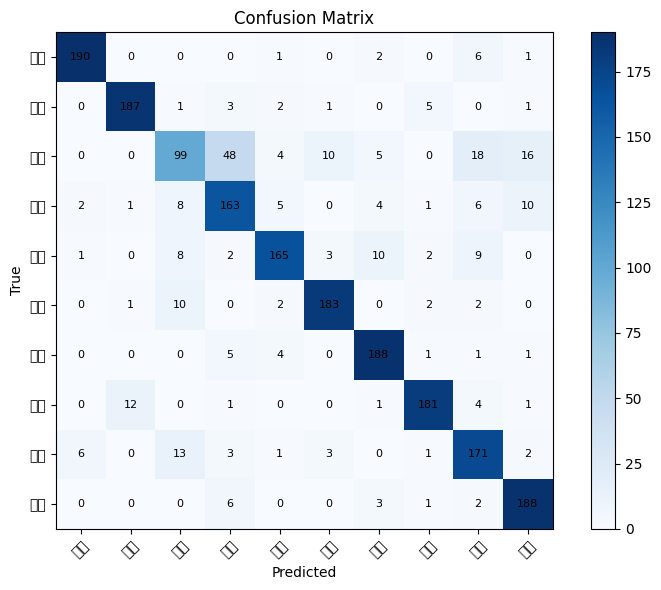

In [12]:
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)

plt.figure(figsize=(8, 6))
plt.imshow(cm_df, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(label_names)), label_names, rotation=45)
plt.yticks(range(len(label_names)), label_names)

for i in range(len(label_names)):
    for j in range(len(label_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=8)

plt.colorbar()
plt.tight_layout()
plt.show()

## 9. 单条新闻预测演示

下面输入几条自定义新闻标题/短文本，展示模型如何给出类别和概率。

In [13]:
def predict_text(text, top_k=3):
    model.eval()
    token_ids, length = encode_text(text)
    x = torch.tensor([token_ids], dtype=torch.long).to(DEVICE)
    lengths = torch.tensor([length], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        logits = model(x, lengths)
        probs = torch.softmax(logits, dim=1)[0].cpu()

    top_probs, top_ids = torch.topk(probs, k=top_k)
    return [
        {
            "label": id2label[idx.item()],
            "probability": round(prob.item(), 4),
        }
        for prob, idx in zip(top_probs, top_ids)
    ]


demo_texts = [
    "中国队在世界杯预选赛中发挥出色，主教练表示球队会继续加强防守和反击。",
    "某科技公司发布新一代人工智能芯片，性能提升明显，将用于云计算和大模型训练。",
    "央行宣布新的货币政策工具，市场分析认为有助于稳定资本市场预期。",
    "热门游戏推出全新赛季版本，新增地图、角色和排位机制。",
]

rows = []
for text in demo_texts:
    preds = predict_text(text)
    rows.append({
        "text": text,
        "top1": preds[0]["label"],
        "top1_prob": preds[0]["probability"],
        "top3": preds,
    })

pd.DataFrame(rows)

,text,top1,top1_prob,top3
0,中国队在世界杯预选赛中发挥出色，主教练表示球队会继续加强防守和反击。,时政,0.6085,"[{'label': '时政', 'probability': 0.6085}, {'lab..."
1,某科技公司发布新一代人工智能芯片，性能提升明显，将用于云计算和大模型训练。,科技,0.8414,"[{'label': '科技', 'probability': 0.8414}, {'lab..."
2,央行宣布新的货币政策工具，市场分析认为有助于稳定资本市场预期。,财经,0.8773,"[{'label': '财经', 'probability': 0.8773}, {'lab..."
3,热门游戏推出全新赛季版本，新增地图、角色和排位机制。,游戏,0.9272,"[{'label': '游戏', 'probability': 0.9272}, {'lab..."


## 10. 保存模型

保存模型参数、标签表和字符表，便于之后重新加载预测。

In [14]:
ckpt_path = ROOT / "lstm_cnews_demo.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_names": label_names,
        "char2id": char2id,
        "config": {
            "max_len": MAX_LEN,
            "max_vocab_size": MAX_VOCAB_SIZE,
            "embed_dim": 128,
            "hidden_size": 128,
            "bidirectional": True,
        },
    },
    ckpt_path,
)

print("模型已保存：", ckpt_path)

模型已保存： D:\steven\hw\rgzn\hw7\lstm_cnews_demo.pt


## 11. 代码逻辑总结

- **数据导入**：从 `cnews.zip` 解压出训练集、验证集、测试集和字符表；
- **预处理**：按 `类别<TAB>正文` 解析样本，将正文转为固定长度的字符 ID 序列；
- **网络结构**：使用 `Embedding + BiLSTM + Dropout + Linear` 完成文本分类；
- **训练策略**：交叉熵损失、Adam 优化器、梯度裁剪；
- **预测方式**：对输入新闻文本做同样的编码，再用 softmax 输出各类别概率。